In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

base_path = '/content/drive/MyDrive/Problem set 1/Archive'

train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'val')
test_dir = os.path.join(base_path, 'test')

print("Total training images:", len(os.listdir(os.path.join(train_dir, 'PNEUMONIA'))))

Total training images: 3875


In [3]:

!cp -r "/content/drive/MyDrive/Problem set 1/Archive" "/content/dataset"

import os

print("Local dataset folders:", os.listdir("/content/dataset"))

Local dataset folders: ['test', '__MACOSX', 'val', 'train']


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


local_path = '/content/dataset'
train_dir = os.path.join(local_path, 'train')
val_dir = os.path.join(local_path, 'val')
test_dir = os.path.join(local_path, 'test')

# 1. data augmentation
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
val_generator = test_val_datagen.flow_from_directory(val_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
test_generator = test_val_datagen.flow_from_directory(test_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

# 2. CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. epoch
model.fit(train_generator, epochs=5, validation_data=val_generator)

# 4. final test result
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 457ms/step - accuracy: 0.8428 - loss: 0.4036 - val_accuracy: 0.7500 - val_loss: 0.6229
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 441ms/step - accuracy: 0.8997 - loss: 0.2447 - val_accuracy: 0.6875 - val_loss: 0.9219
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 429ms/step - accuracy: 0.9183 - loss: 0.2148 - val_accuracy: 0.6875 - val_loss: 0.5838
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 452ms/step - accuracy: 0.9172 - loss: 0.2170 - val_accuracy: 0.6875 - val_loss: 0.7406
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 465ms/step - accuracy: 0.9212 - loss: 0.1935 - val_accuracy: 0.8125 - val_loss: 0.6174
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - accuracy: 0.8349 - loss: 0.4996

Final Test Accuracy: 83.49%


In [10]:
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(input_shape=(150, 150, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False

model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

/tmp/ipykernel_9447/1305196948.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(150, 150, 3),


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 530ms/step - accuracy: 0.8537 - loss: 0.3419 - val_accuracy: 0.6875 - val_loss: 0.7115
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 439ms/step - accuracy: 0.9155 - loss: 0.2185 - val_accuracy: 0.6875 - val_loss: 0.6981
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.9264 - loss: 0.1878 - val_accuracy: 0.6875 - val_loss: 0.7444
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.9365 - loss: 0.1666 - val_accuracy: 0.6875 - val_loss: 0.6394
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 440ms/step - accuracy: 0.9339 - loss: 0.1624 - val_accuracy: 0.6875 - val_loss: 0.6652
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 441ms/step - accuracy: 0.9388 - loss: 0.1530 - val_accuracy: 0.6875 - val_loss: 0.7119
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 440ms/step - accuracy: 0.9436 - loss: 0.1489 - val_accuracy: 0.7500 - val_loss: 0.5098
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 441ms/step - accuracy: 0.9496 - loss: 

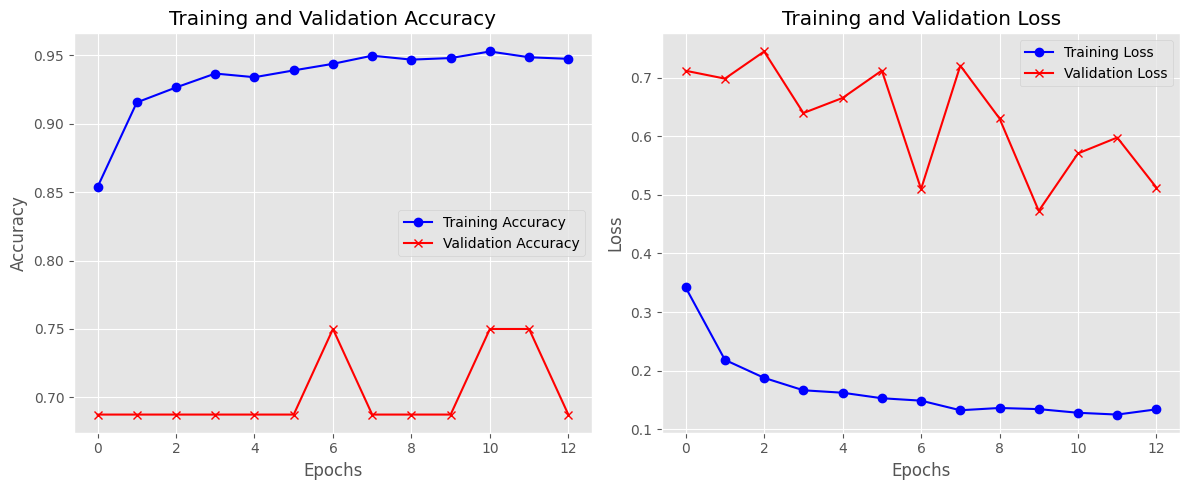

In [14]:
import matplotlib.pyplot as plt


plt.style.use('ggplot')


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', marker='x')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()